# Validation Pipeline Sketch V3
## 0. Imports and Set-Up:

### 0.1 Imports, Seed-Setting, Plotting-Helper-Function:

In [62]:
import multiprocessing
import random
import warnings

from dataclasses import dataclass, field
from itertools import product
from joblib import Parallel, delayed
from pathlib import Path
from typing import Type, Any, Optional

from tqdm.notebook import tqdm

import numpy as np
import pandas as pd

from sklearn.base import ClusterMixin
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import adjusted_rand_score, pairwise_distances
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, FunctionTransformer, StandardScaler

from umap import UMAP

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
col_pal = sns.color_palette("rainbow", n_colors=8)

sns.set_theme(
    style="whitegrid",
    palette=col_pal,
    font_scale=1.2,
    rc={
        "axes.edgecolor": ".2",
        "grid.color": ".8",
        "grid.linewidth": 0.8,
        "figure.figsize": (8, 5),
        "axes.prop_cycle": plt.cycler(color=col_pal)
    }
)

sns.set_context("notebook", rc={"lines.linewidth": 2, "font.size": 14})

### 0.2 Helper Functions:

In [4]:
def plot_dim_reduced_clustering(
    X: np.ndarray, 
    clusters: np.ndarray, 
    method: str = 'PCA', 
    perplexity: int = 30, 
    n_neighbors: int = 15, 
    min_dist: float = 0.1,
    ax: plt.Axes = None, 
    show: bool = True
) -> plt.Axes:
    """
    Plot a 2D embedding of the data colored by cluster assignments.

    :param X: the input data matrix to be reduced and plotted (n_samples, n_features)
    :param clusters: cluster labels for each sample (n_samples,)
    :param method: dimensionality reduction method to use; either 'PCA' or 'tSNE'
    :param ax: a matplotlib axes object to be plotted on
    :param show: controls whether to call plt.show()

    :return: plt.Axes if show = False, otherwise displays a scatter plot with the samples colored by cluster assignment
    """
    # dimensionality reduction
    if method == 'PCA':
        X_red = PCA(n_components=2, random_state=RANDOM_SEED).fit_transform(X)
    elif method == 'tSNE':
        X_red = TSNE(
            n_components=2,
            random_state=RANDOM_SEED,
            perplexity=perplexity
        ).fit_transform(X)
    elif method == 'UMAP':
        X_red = UMAP(
            n_components=2, 
            n_neighbors=n_neighbors, 
            min_dist=min_dist, 
            random_state=RANDOM_SEED  # throws a warning
        ).fit_transform(X)
    else:
        raise ValueError(f"Unknown dimensionality reduction method {method}. Use one of 'PCA', 'tSNE', or 'UMAP'.")

    # build discrete colormap for clusters
    unique_clusters = np.unique(clusters)
    base_cmap = plt.get_cmap('Set1', len(unique_clusters))
    color_dict = {lab: base_cmap(i) for i, lab in enumerate(unique_clusters)}

    # plot points
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 8))
    point_colors = [color_dict[lab] for lab in clusters]
    ax.scatter(X_red[:, 0], X_red[:, 1], c=point_colors, s=10, alpha=0.8)

    # handle legend
    for lab in unique_clusters:
        ax.scatter([], [], c=[color_dict[lab]], label=f"cluster {lab}", s=50, alpha=0.8)
        
    ax.legend(loc='lower right', frameon=False)

    # titles & axis labels
    if method == 'PCA':
        ax.set(
            title="PCA of TCGA Pan-Cancer gene expression",
            xlabel="PCA 1",
            ylabel="PCA 2"
        )
    elif method == 'tSNE':
        ax.set(
            title="t-SNE of TCGA Pan-Cancer gene expression",
            xlabel="t-SNE 1",
            ylabel="t-SNE 2"
        )
    else:
        ax.set(
            title="UMAP of TCGA Pan-Cancer gene expression",
            xlabel="UMAP 1",
            ylabel="UMAP 2"
        )

    if show:
        plt.tight_layout()
        plt.show()
    else:
        return ax

In [5]:
def subsample_indices(n_samples: int, ratio: float = 0.8, random_state: int = None) -> tuple[np.ndarray, np.ndarray]:
    """
    draw a subsample of indices of size floor(ratio * n_samples).
    
    :param n_samples: total number of samples in data frame.
    :param ratio: ratio for subsampling, between 0 and 1. 
    :param random_state: random seed for rng.
    
    :return:
        train_idx: 1D array of length floor(ratio * n_samples).
        test_idx: the complement indices (length = n_samples - len(train_idx)).
    """
    rng = np.random.RandomState(random_state)
    all_idx = np.arange(n_samples)
    train_size = int(np.float64(ratio * n_samples))
    
    train_idx = rng.choice(all_idx, size=train_size, replace=False)
    test_idx = np.setdiff1d(all_idx, train_idx)
    
    return train_idx, test_idx

In [6]:
def update_consensus_count(C: np.ndarray, labels_full: np.ndarray) -> None:
    """
    increment C[i,j] by 1 for every pair i,j that share the same cluster label.
    
    :param C: consensus matrix.
    :param labels_full: 1D array length = n_samples, where each entry is an integer cluster ID.
    
    :return: None (C is updated in place)
    """
    for cluster_id in np.unique(labels_full):
        members = np.where(labels_full == cluster_id)[0]
        
        for i in members:
            C[i, members] += 1
    
    return None

### 0.3 Data Import:

PANCAN dataset:

In [7]:
data_dir = Path('./data/TCGA-PANCAN-HiSeq-801x20531')
data_fp = data_dir / 'data.csv'
labels_fp = data_dir / 'labels.csv'

labels = pd.read_csv(labels_fp, header=None, skiprows=1)

sample = pd.read_csv(data_fp, header=None, skiprows=1, nrows=100, low_memory=False)
numeric_cols = [
    col
    for col in sample.columns
    if pd.to_numeric(sample[col], errors='coerce').notna().all()
]

print(f"found {len(numeric_cols)} numeric cols out of {len(sample.columns)}")

data = pd.read_csv(
    data_fp,
    header=None,
    usecols=numeric_cols,
    skiprows=1, 
    dtype=float,
    low_memory=False
)

le = LabelEncoder()
y = le.fit_transform(labels[1])

X = data.values

print("X shape:", X.shape, " |  y shape:", y.shape)

found 20531 numeric cols out of 20532
X shape: (801, 20531)  |  y shape: (801,)


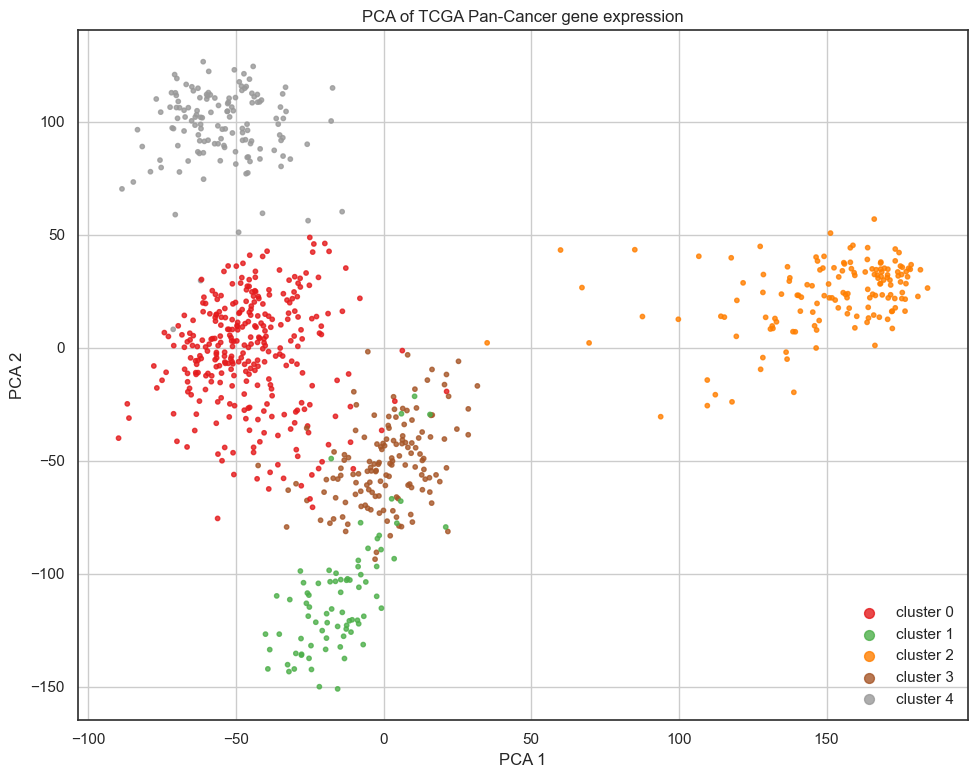

In [8]:
plot_dim_reduced_clustering(X, y, method='PCA')

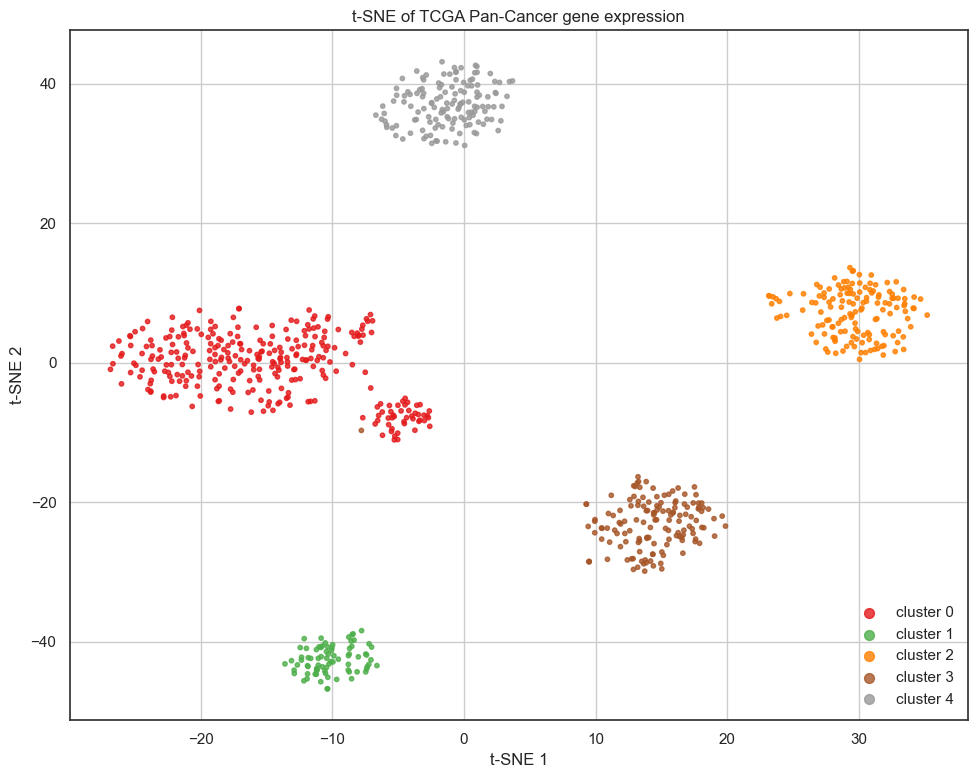

In [9]:
plot_dim_reduced_clustering(X, y, method='tSNE')

/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


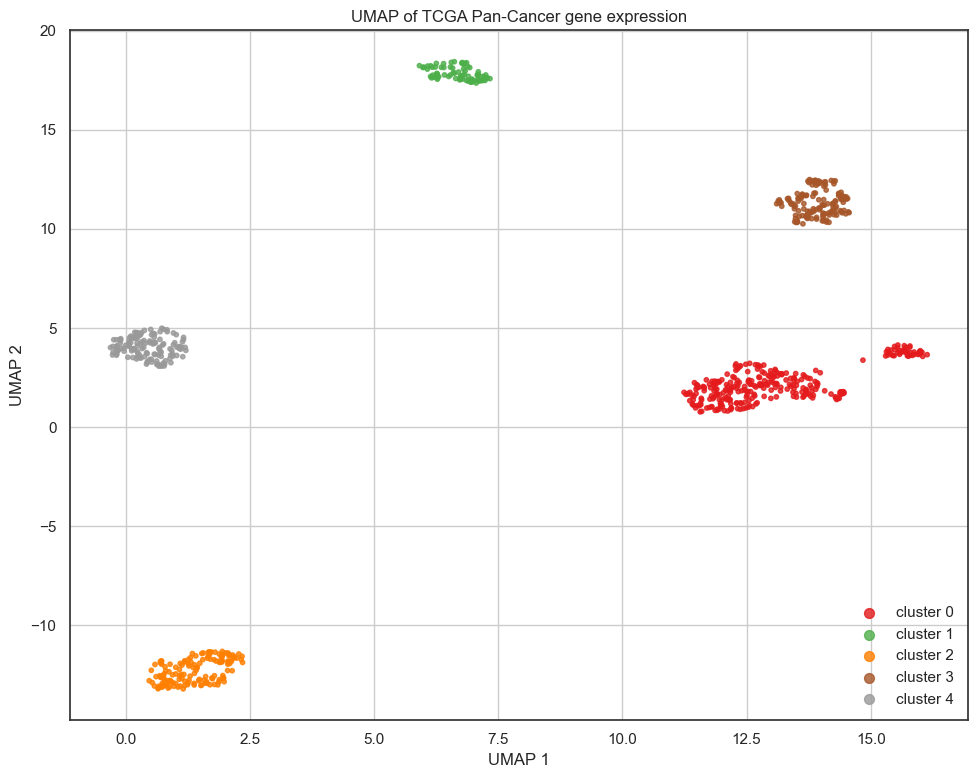

In [10]:
plot_dim_reduced_clustering(X, y, method='UMAP')

Or IRIS dataset:

In [11]:
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

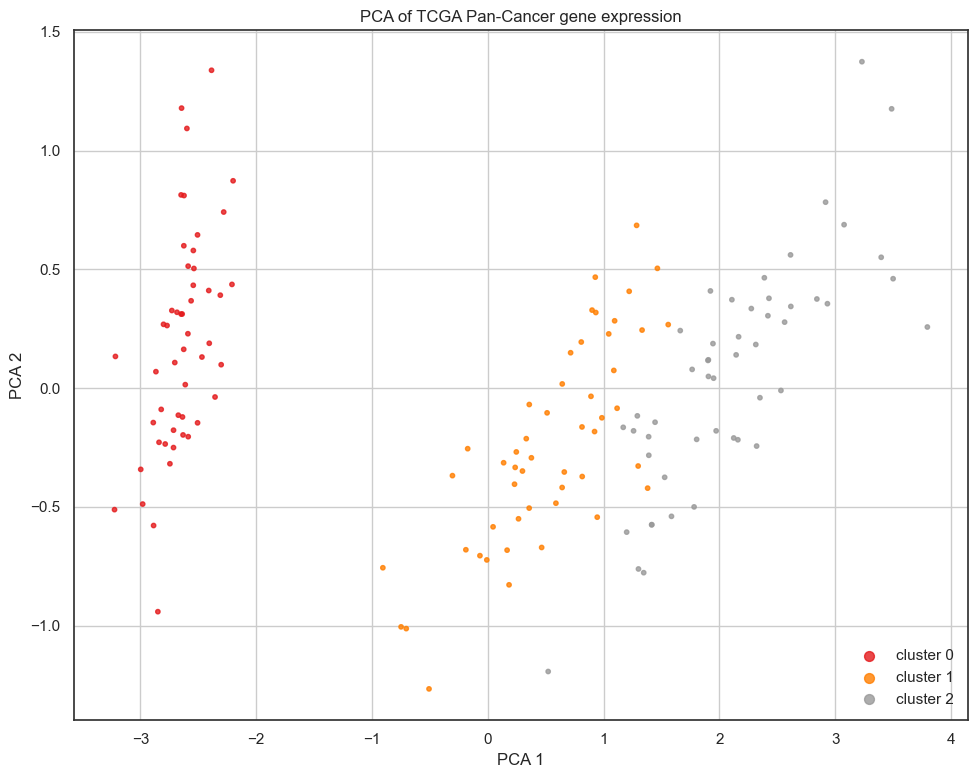

In [12]:
plot_dim_reduced_clustering(X, y, method='PCA')

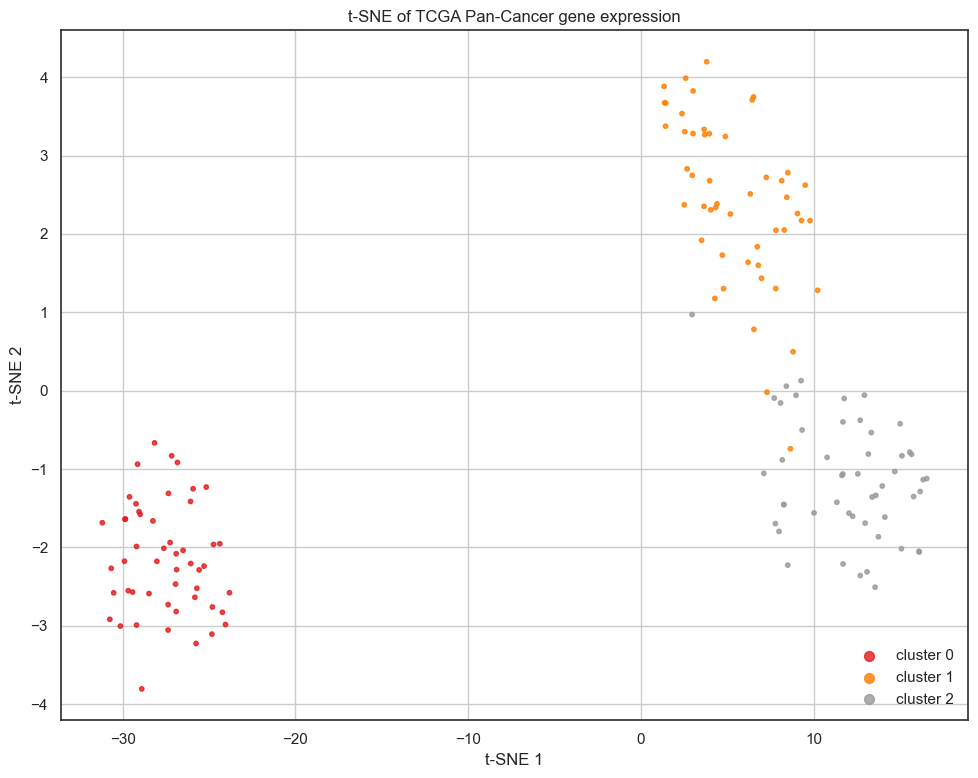

In [13]:
plot_dim_reduced_clustering(X, y, method='tSNE')

/Users/kaiwycik/.pyenv/versions/3.12.10/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


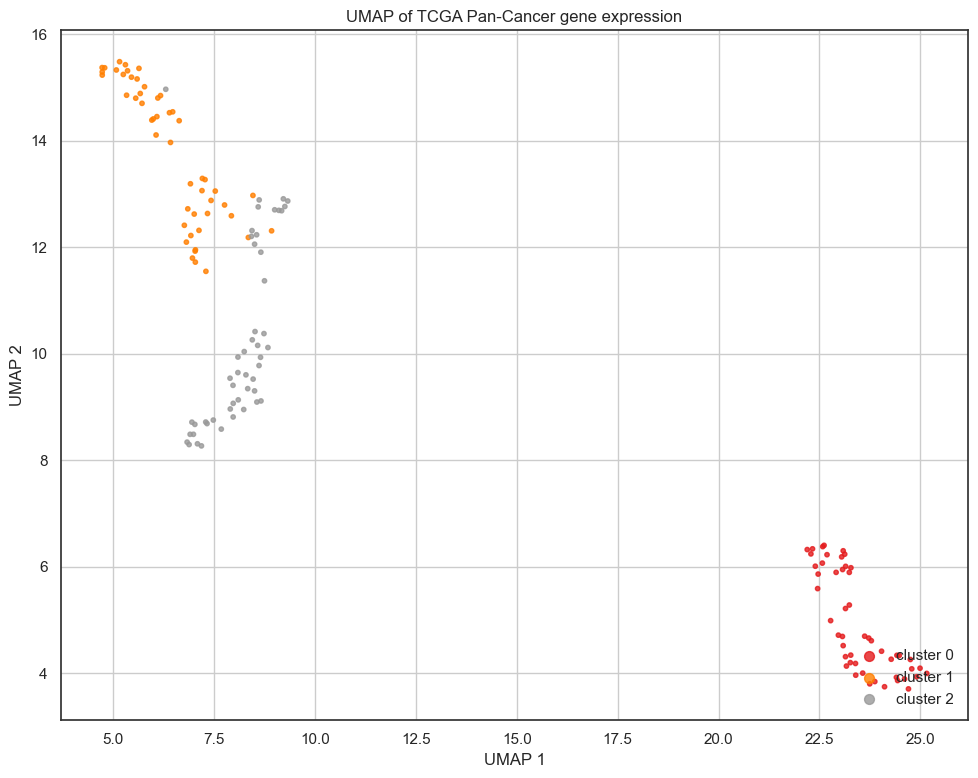

In [14]:
plot_dim_reduced_clustering(X, y, method='UMAP')

---

## 1. Validation Function:

In [35]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning


In utils.py:

In [64]:
def get_preprocessing(
    normalization_method: str = 'normal',
    dim_red_method: str = 'PCA', 
    n_components: int = 50, 
    perplexity: int = 30, 
    n_neighbors: int = 15, 
    min_dist: float = 0.1
) -> Pipeline:
    """
    perform data normalization and dimensionality reduction.

    :param normalization_method: normalization method to be applied; one of 'raw', 'normal', or 'l1p'
    :param dim_red_method: dimensionality reduction technique to use; one of 'raw', 'PCA', 'tSNE', or 'UMAP'
    :param n_components: target number of components for dimensionality reduction
    :param perplexity: perplexity parameter for t-SNE (only if dim_red_method == 'tSNE')
    :param n_neighbors: number of neighbors for UMAP (only if dim_red_method == 'UMAP')
    :param min_dist: minimum distance between points in UMAP embedding (only if dim_red_method == 'UMAP')

    :return: sklearn Pipeline object
    """
    steps = []
    # normalization
    if normalization_method == 'raw':
        steps.append(('norm', FunctionTransformer(lambda X: X)))
    elif normalization_method == 'normal':
        steps.append(('norm', StandardScaler()))
    elif normalization_method == 'l1p':
        steps.append(('norm', FunctionTransformer(np.log1p)))
    # dim reduction
    if dim_red_method == 'raw':
        steps.append(('dr', FunctionTransformer(lambda X: X)))
    elif dim_red_method == 'PCA':
        steps.append(('dr', PCA(n_components=n_components, random_state=RANDOM_SEED)))
    elif dim_red_method == 'tSNE':
        steps.append(('dr', TSNE(n_components=n_components, perplexity=perplexity, random_state=RANDOM_SEED)))
    elif dim_red_method == 'UMAP':
        steps.append(('dr', UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist, random_state=RANDOM_SEED)))
        
    return Pipeline(steps)

def clustering_pipeline(
    X: np.ndarray,
    estimator: Type[ClusterMixin],
    **params
) -> np.ndarray:
    """
    Cluster data using a scikit-learn estimator and parameter dict.

    :param X: data array of shape (n_samples, n_features)
    :param estimator: clustering class implementing fit_predict (e.g. KMeans)
    :param params: hyperparameters for the estimator
    
    :return: cluster labels array
    """
    
    model = estimator(**params)
    return model.fit_predict(X)

In [102]:
@dataclass
class ClusteringValidator:
    """
    Validate clustering stability and generalizability across estimator grids.

    :param X: input data, shape (n_samples, n_features)
    :param grids: list of tuples (estimator_class, param_grid)
    :param B: number of bootstrap iterations per config
    :param rho: subsampling ratio for splits
    :param num_cores: parallel jobs count
    """
    X: np.ndarray
    K: int = 10
    grids: Optional[list[tuple[Type[ClusterMixin], dict[str, list[Any]]]]] = None
    B: int = 20
    rho: float = 0.8
    num_cores: int = field(default_factory=lambda: max(1, multiprocessing.cpu_count() - 1))

    def __post_init__(self):
        """
        Initialize default grids if none provided.
        """
        if self.grids is None:
            D2 = pairwise_distances(self.X, metric='sqeuclidean')
            median_d2 = np.median(D2[np.triu_indices_from(D2, k=1)])
            gamma0 = 1.0 / (2.0 * median_d2)

            self.grids = [
                (KMeans, {'n_clusters': list(range(2, self.K+1))}),
                (AgglomerativeClustering, {'n_clusters': list(range(2, self.K+1)), 'linkage': ['ward','complete','average','single']}),
                (SpectralClustering, {'n_clusters': list(range(2, self.K+1)), 'gamma': list(np.logspace(np.log10(gamma0)-1, np.log10(gamma0)+1, num=4))})
            ]

    def _validation_iter(
        self,
        est_class: Type[ClusterMixin],
        params: dict[str, Any],
        seed: int
    ) -> tuple[float, float]:
        """
        Perform single iteration of clustering + ARI evaluation.

        :param est_class: clustering estimator class
        :param params: estimator hyperparameters
        :param seed: random seed for reproducibility
        
        :return: (model-explorer ARI, predictive ARI)
        """
        rnd = random.Random(seed)
        n_samples, p = self.X.shape

        # Random preprocessing choices
        norm = rnd.choice(['raw', 'normal', 'l1p'])
        dr = rnd.choice(['raw', 'PCA', 'tSNE', 'UMAP'])
        n_comp = rnd.randint(2, min(n_samples, p))
        perp = nneigh = None
        if dr == 'tSNE':
            n_comp = rnd.randint(2, 3)
            perp = rnd.randint(5, int(round(n_samples * (1 - self.rho))) - 1)
        elif dr == 'UMAP':
            nneigh = rnd.randint(5, 50)

        # Subsample indices for splits
        A_train_idx, A_test_idx = subsample_indices(n_samples, self.rho, seed)
        B_idx, _ = subsample_indices(n_samples, self.rho, seed + self.B)

        # Preprocess data
        proc = get_preprocessing(norm, dr, n_comp, perp, nneigh)
        X1 = proc.fit_transform(self.X[A_train_idx])
        X2 = proc.fit_transform(self.X[A_test_idx])
        X3 = proc.fit_transform(self.X[B_idx])

        # Cluster and measure ARI
        labels1 = clustering_pipeline(X1, est_class, **params)
        labels2 = clustering_pipeline(X2, est_class, **params)
        labels3 = clustering_pipeline(X3, est_class, **params)

        _, i1, i3 = np.intersect1d(A_train_idx, B_idx, return_indices=True)
        ari1 = adjusted_rand_score(labels1[i1], labels3[i3])

        rf = RandomForestClassifier(
            n_estimators=100,
            max_depth=p,
            max_features=int(np.sqrt(p)),
            random_state=seed
        )
        rf.fit(X1, labels1)
        pred = rf.predict(X2)
        ari2 = adjusted_rand_score(labels2, pred)

        return ari1, ari2

    def run(self) -> pd.DataFrame:
        """
        Run validation across all estimators and parameter grids.

        :return: DataFrame with columns ['estimator', *param_keys, 'ari_model_explorer', 'ari_predictive']
        """
        total = sum(len(list(ParameterGrid(grid))) for _, grid in self.grids)
        
        records = []
        
        with tqdm(total=total, desc="Grid configs") as pbar:
            for est_class, grid in self.grids:
                for params in ParameterGrid(grid):
                    worker = delayed(self._validation_iter)
                    
                    results = Parallel(n_jobs=self.num_cores)(
                        worker(est_class, params, b) for b in range(self.B)
                    )
                    
                    ari1 = np.mean([r for r, _ in results])
                    ari2 = np.mean([p for _, p in results])

                    row = {
                        'estimator': est_class.__name__,
                        **params,
                        'ari_model_explorer': ari1,
                        'ari_predictive': ari2
                    }
                    
                    records.append(row)
                    pbar.update(1)
                    
        return pd.DataFrame.from_records(records)
    
    def run_preprocessed(self) -> pd.DataFrame:
        """
        Run validation on pre-processed data (no random preprocessing).
        
        :return: DataFrame with columns ['estimator', *param_keys, 'ari_model_explorer', 'ari_predictive']
        """
        total = sum(len(list(ParameterGrid(grid))) for _, grid in self.grids)
        
        records = []
        
        with tqdm(total=total, desc="Grid configs") as pbar:
            for est_class, grid in self.grids:
                for params in ParameterGrid(grid):
                    # subsample and clustering
                    results = []
                    for b in range(self.B):
                        # subsample indices
                        n_samples = X.shape[0]
                        A_train_idx, A_test_idx = subsample_indices(n_samples, self.rho, b)
                        B_idx, _ = subsample_indices(n_samples, self.rho, b + self.B)
                        
                        # clustering directly
                        labels1 = clustering_pipeline(X[A_train_idx], est_class, **params)
                        labels2 = clustering_pipeline(X[A_test_idx], est_class, **params)
                        labels3 = clustering_pipeline(X[B_idx],  est_class, **params)
                        
                        # model-explorer ARI
                        _, i1, i3 = np.intersect1d(A_train_idx, B_idx, return_indices=True)
                        ari1 = adjusted_rand_score(labels1[i1], labels3[i3])
                        
                        # predictive ARI
                        rf = RandomForestClassifier(
                            n_estimators=100, 
                            max_depth=X.shape[1],
                            max_features=int(np.sqrt(X.shape[1])),
                            random_state=b
                        )
                        rf.fit(X[A_train_idx], labels1)
                        pred = rf.predict(X[A_test_idx])
                        ari2 = adjusted_rand_score(labels2, pred)
                        
                        results.append((ari1, ari2))
                        
                    # aggregate
                    ari_model = np.mean([r for r, _ in results])
                    ari_pred  = np.mean([p for _, p in results])
                    
                    row = {
                        'estimator': est_class.__name__, **params,
                        'ari_model_explorer': ari_model,
                        'ari_predictive': ari_pred
                    }
                    
                    records.append(row)
                    pbar.update(1)
        
        return pd.DataFrame.from_records(records)

Provide custom grid and models:

In [97]:
# from sklearn.cluster import DBSCAN, Birch

# grids = [
#     (DBSCAN, {'eps': [0.3, 0.5, 0.7], 'min_samples': [5, 10]}),
#     (Birch, {'n_clusters': [2, 3, 4], 'threshold': [0.5, 1.0]})
# ]

# validator = ClusteringValidator(X, grids=grids, B=30, rho=0.8)
# df = validator.run()

# df

Or run on pre-defined models:

In [103]:
validator = ClusteringValidator(X)
df = validator.run_preprocessed()

df

Grid configs:   0%|          | 0/81 [00:00<?, ?it/s]

,estimator,n_clusters,ari_model_explorer,ari_predictive,linkage,gamma
0,KMeans,2,0.989604,0.915153,NaN,NaN
1,KMeans,3,0.920093,0.745425,NaN,NaN
2,KMeans,4,0.787061,0.650908,NaN,NaN
3,KMeans,5,0.644181,0.611870,NaN,NaN
4,KMeans,6,0.726179,0.590597,NaN,NaN
...,...,...,...,...,...,...
76,SpectralClustering,6,0.830890,0.498725,NaN,0.897666
77,SpectralClustering,7,0.648024,0.512029,NaN,0.897666
78,SpectralClustering,8,0.757402,0.463037,NaN,0.897666
79,SpectralClustering,9,0.742454,0.469215,NaN,0.897666


In [104]:
best_model = df.loc[df['ari_model_explorer'].idxmax()]
best_pred = df.loc[df['ari_predictive'].idxmax()]

print("global best model_explorer_ARI:", best_model.to_dict())

global best model_explorer_ARI: {'estimator': 'AgglomerativeClustering', 'n_clusters': 2, 'ari_model_explorer': 1.0, 'ari_predictive': 0.9812394177217886, 'linkage': 'ward', 'gamma': nan}


In [105]:
opt_labels = AgglomerativeClustering(n_clusters=2, linkage='ward').fit_predict(X)

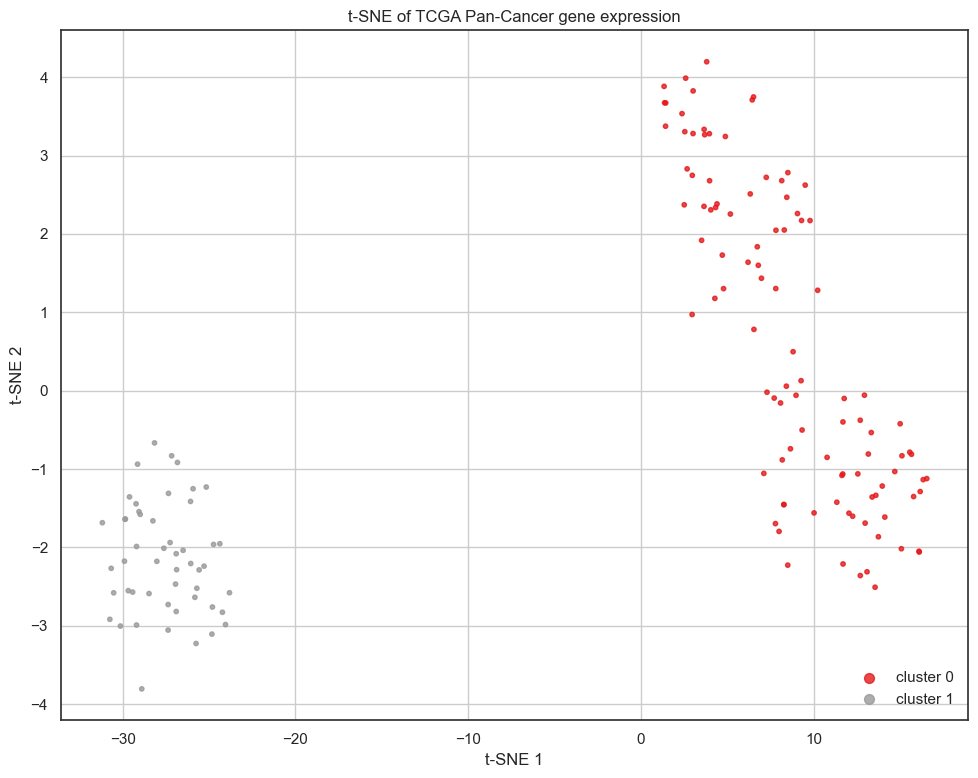

In [106]:
plot_dim_reduced_clustering(X, opt_labels, method='tSNE')

In [107]:
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.optimize import linear_sum_assignment

def map_clusterings(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    row_idx, col_idx = linear_sum_assignment(-cm)
    return dict(zip(col_idx, row_idx))

mapping = map_clusterings(y, opt_labels)

opt_labels_mapped = np.vectorize(mapping.get)(opt_labels)
print('accuracy:', accuracy_score(y, opt_labels_mapped))

accuracy: 0.6666666666666666
